In [1]:
import numpy as np
import smplx
import trimesh
import torch
import os
import utils
import pyembree
import plotly.express as px
import plotly.graph_objects as go
import json

%load_ext autoreload
%autoreload 2


In [2]:
fig = utils.plot_random_pose(n_points=5_000)

Randomly chosen file: male_run.npz
Randomly chosen index: 72


In [3]:
fig.show()

In [4]:
points, mesh = utils.sampled_verts_from_random_action(return_mesh=True)

Randomly chosen file: male_walk_turn_left_90.npz
Randomly chosen index: 288


In [5]:
camera = np.array(
    [points[:,0].max() * 1.2
    , points[:,1].max() * 1.2
    , points[:,2].max() * 1.2]
)

#camera = np.array([-3, -3, 2])

utils.plot_arr(np.append(points, camera.reshape(1, 3), axis = 0))

In [6]:

# mesh: trimesh.Trimesh
# points: (N, 3) sampled points on the mesh
# camera: (3,) camera position

# Direction vectors from camera to points
dirs = points - camera
dists = np.linalg.norm(dirs, axis=1)
dirs = dirs / dists[:, None]

# Small epsilon to avoid self-intersection
epsilon = 1e-6
origins = np.repeat(camera[None, :], len(points), axis=0) + epsilon * dirs

# Ray-mesh intersection
locations, index_ray, index_tri = mesh.ray.intersects_location(
    ray_origins=origins,
    ray_directions=dirs,
    multiple_hits=False
)

# Distance from camera to first hit
hit_dists = np.linalg.norm(locations - camera, axis=1)

# Initialize visibility mask
visible = np.zeros(len(points), dtype=bool)

# A point is visible if the first hit is at (approximately) the point
visible[index_ray] = np.isclose(
    hit_dists,
    dists[index_ray],
    atol=1e-5
)

visible_points = points[visible]


In [7]:
utils.plot_arr(points)

In [8]:
utils.plot_arr(np.append(visible_points, camera.reshape(1, 3), axis = 0))

In [9]:
visible_points = utils.remove_occluded_points(points, mesh, camera)

In [10]:
utils.plot_arr(np.append(visible_points, camera.reshape(1, 3), axis = 0))

In [11]:
utils.plot_arr(utils.sampled_verts_from_random_action())

Randomly chosen file: female_walk_to_run.npz
Randomly chosen index: 581


In [12]:
p = utils.choose_random_file()
utils.mesh_from_path(p)

Randomly chosen file: female_walk_to_run.npz


<trimesh.Trimesh(vertices.shape=(10475, 3), faces.shape=(20908, 3))>

In [13]:
path_to_datasets = "datasets/action_smplx_models"

In [14]:
files = os.listdir(path_to_datasets)

In [15]:
np.load(path_to_datasets + "/female_walk.npz")["pose_body"].shape[0]

915

In [16]:
m = utils.mesh_from_path(p)

In [17]:
utils.sampled_verts_from_mesh(m)

(TrackedArray([[ 3.17454312, -2.884422  ,  1.72907124],
               [ 3.31498023, -2.91938906,  1.11943814],
               [ 3.20995769, -2.99960484,  0.53613237],
               ...,
               [ 3.16991872, -2.93296336,  0.70702796],
               [ 3.14308646, -2.86325686,  1.65462639],
               [ 3.24399173, -3.06092397,  1.28135067]], shape=(1000, 3)),)

In [18]:
walk_meshes, run_meshes = utils.get_walk_run_meshes()

female_walk.npz
male_walk_turn_left_90.npz
female_run.npz
male_run.npz


In [19]:
walk_points = utils.sample_from_meshes(walk_meshes)

In [20]:
run_points = utils.sample_from_meshes(run_meshes)

In [21]:
idx = np.random.choice(range(walk_points.shape[0]))
utils.plot_arr(walk_points[idx])

In [22]:
import ot
import scipy
import matplotlib.pyplot as plt
import sklearn
import pandas as pd

In [23]:
ref_measure = np.random.randn(3000).reshape(-1, 3)

In [24]:
a = np.ones(1000) / 1000
b = np.ones(1000) / 1000
M = ot.dist(ref_measure, walk_points[0])

In [25]:
G = ot.solve(M, a, b).plan

In [26]:
bary = G @ walk_points[0]

In [27]:
bary.flatten()

array([2.88401263e-03, 2.76109822e-03, 5.21227874e-05, ...,
       3.24365130e-03, 2.85914537e-03, 8.93241588e-04], shape=(3000,))

In [28]:
walk_points_flattened = []
for i in range(walk_points.shape[0]):
    M = ot.dist(ref_measure, walk_points[i])
    G = ot.solve(M, a, b).plan
    bary = G @ walk_points[i]
    walk_points_flattened.append(bary.flatten())

run_points_flattened = []
for i in range(run_points.shape[0]):
    M = ot.dist(ref_measure, run_points[i])
    G = ot.solve(M, a, b).plan
    bary = G @ run_points[i]
    run_points_flattened.append(bary.flatten())

In [29]:
pca = sklearn.decomposition.PCA(n_components=2)

In [30]:
all_points = np.array(walk_points_flattened + run_points_flattened)

In [31]:
len(walk_points_flattened)

1519

In [32]:
all_points_pca = pca.fit_transform(all_points)

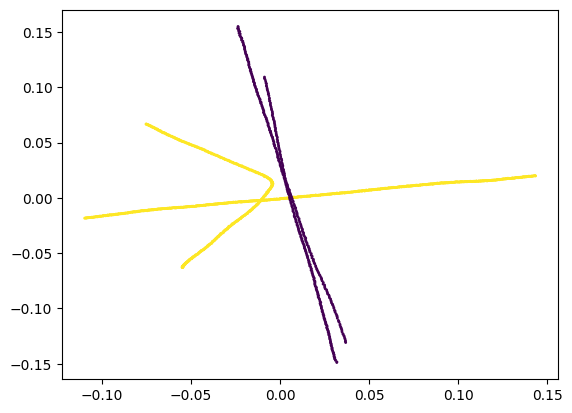

In [33]:
c = [1] * len(walk_points_flattened) + [0] * len(run_points_flattened)
plt.scatter(x = all_points_pca[:,0], y = all_points_pca[:,1], c = c, s = 1)

at some point we should maybe add in stuff like random rotations and stuff to get more data

In [34]:
svm = sklearn.svm.SVC()

In [35]:
label = np.array([0] * len(walk_points_flattened) + [1] * len(run_points_flattened))

In [36]:
df = pd.DataFrame(all_points)

In [37]:
df["label"] = label

In [38]:
shuffled = df.sample(df.shape[0], replace=False).to_numpy()
train = shuffled[:shuffled.shape[0] * 3 // 4, :]
test = shuffled[shuffled.shape[0] * 3 // 4:, :]

In [39]:
svm.fit(train[:, :-1], train[:, -1])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
preds = svm.predict(test[:, :-1])

In [41]:
(preds == test[:,-1]).mean()

np.float64(0.970703125)

In [42]:
1 - test[:,-1].mean()

np.float64(0.755859375)

In [43]:
mesh = utils.mesh_from_path("datasets/action_smplx_models/male2_Calibration_stageii.npz")

In [44]:
points, faces = utils.sampled_verts_from_mesh(mesh, return_faces=True, n_points=50000)
# 20908 total faces
mask = faces <= 20809 / 2
utils.plot_arr(points, color = mask.astype(int))

In [45]:
from collections import defaultdict, deque
import math

def graph_distances_from_vertex(x, adjacency_pairs):
    """
    Parameters
    ----------
    x : int
        Source vertex
    adjacency_pairs : array-like of shape (N, 2)
        Each entry [a, b] means a and b are adjacent (undirected)

    Returns
    -------
    distances : dict
        {vertex: distance from x in number of adjacencies}
        Unreachable vertices have distance = inf
    """
    # Build adjacency list
    adj = defaultdict(list)
    vertices = set()

    for a, b in adjacency_pairs:
        adj[a].append(b)
        adj[b].append(a)
        vertices.add(a)
        vertices.add(b)

    # Initialize distances
    distances = {v: -1 for v in vertices}
    distances[x] = 0

    # BFS
    queue = deque([x])
    print(queue)

    while queue:
        v = queue.popleft()
        for u in adj[v]:
            if distances[u] == -1:
                distances[u] = distances[v] + 1
                queue.append(u)

    return distances


In [46]:
dists = graph_distances_from_vertex(0, mesh.face_adjacency)

deque([0])


In [47]:
np.vectorize(dists.get)(faces)

array([104,  62,  76, ...,  71, 106, 124], shape=(50000,))

In [48]:
utils.plot_arr(points, color = np.vectorize(dists.get)(faces), colorbar = True)

In [49]:
path = "datasets/action_smplx_models/male_run.npz"

In [50]:
utils.plot_arr(utils.sampled_verts_from_path(path, idx = 0, n_points = 10_000))

In [51]:
utils.plot_arr(utils.sampled_verts_from_path(path, idx = 120, n_points = 1_000))

In [52]:
frame1 = utils.sampled_verts_from_path(path, idx = 0, n_points = 1_000)
frame2 = utils.sampled_verts_from_path(path, idx = 10, n_points = 1_000)

In [53]:
M = ot.dist(frame1, frame2)
a = np.ones(1000)/1000
b = np.ones(1000)/1000
G = ot.solve(M, a, b).plan

In [54]:
utils.plot_3d_points_and_connections(frame1, frame2, G, switch_yz=False)

In [55]:
mesh = utils.mesh_from_path("datasets/action_smplx_models/male2_Calibration_stageii.npz")

In [56]:
points, faces = utils.sampled_verts_from_mesh(mesh, return_faces=True, n_points=50000)

In [57]:
x = mesh.vertices[:,0]
y = mesh.vertices[:,1]
z = mesh.vertices[:,2]
mask = (x > -0.9) & (x < -0.7)
utils.plot_arr(mesh.vertices, color = mask.astype(int))

In [58]:
face_centers = []
for i in range(mesh.faces.shape[0]):
    this_face = mesh.faces[i]
    these_verts = mesh.vertices[this_face]
    face_centers.append(these_verts.mean(axis = 0))
face_centers = np.array(face_centers)

In [59]:
x = face_centers[:,0]
y = face_centers[:,1]
z = face_centers[:,2]
mask = (x > -0.95) & (x < -0.7)
mask = (x >= -0.7) & (x <= -0.5)


utils.plot_arr(face_centers, color = mask.astype(int))

In [60]:
mask_dict = {}
mask_dict["left_forearm"] = (x > -0.95) & (x < -0.7)
mask_dict["left_hand"] = (x <= -0.95)
mask_dict["right_forearm"] = (x < 2 * x.mean()-(-0.95)) & (x > 2 * x.mean()-(-0.7))
mask_dict["right_hand"] = (x >= 2 * x.mean()-(-0.95))
mask_dict["left_upper_arm"] = (x >= -0.7) & (x <= -0.5)
mask_dict["right_upper_arm"] = (x <= 2 * x.mean()-(-0.7)) & (x >= 2 * x.mean() - (-0.5))
mask_dict["head"] = (x >= -.5) & (x <= 2 * x.mean() - (-.5)) & ((z + y > 1.61)| (z > 1.53))
mask_dict["upper_torso"] = (x >= -.5) & (x <= 2 * x.mean() - (-.5)) & ((z + y <= 1.61) & (z <= 1.53)) & (z > 1.2)
mask_dict["lower_torso"] = (x >= -.5) & (x <= 2 * x.mean() - (-.5)) & (z <= 1.2) & ((z + y > 1.1) | (z > 1))
mask_dict["pelvis"] = ((z + y <= 1.1) & (z <= 1)) & (-np.abs(x - x.mean()) + z > .67)
mask_dict["left_thigh"] = (-np.abs(x - x.mean()) + z <= .67) & (z > .45) & (x <= x.mean())
mask_dict["right_thigh"] = (-np.abs(x - x.mean()) + z <= .67) & (z > .45) & (x > x.mean())
mask_dict["left_shin"] = (z <= .45) & (x <= x.mean()) & (z >= .08)
mask_dict["right_shin"] = (z <= .45) & (x > x.mean()) & (z >= .08)
mask_dict["left_foot"] = (x <= x.mean()) & (z < .08)
mask_dict["right_foot"] = (x > x.mean()) & (z < .08)

In [61]:
run_mesh = utils.mesh_from_path("datasets/action_smplx_models/male_run.npz", idx = 0)


In [62]:
# Distinct Plotly-friendly colors (hex strings)
colors = [
    "#636EFA",  # blue
    "#EF553B",  # red
    "#00CC96",  # green
    "#AB63FA",  # purple
    "#FFA15A",  # orange
    "#19D3F3",  # cyan
    "#FF6692",  # pink
    "#B6E880",  # light green
    "#FF97FF",  # magenta
    "#FECB52",  # yellow
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

mask_color = {}
for key, color in zip(mask_dict.keys(), colors):
    mask_color[key] = color


In [190]:
iter = 0
color = []
to_plot = np.array([0,0,0]).reshape(-1, 3)
for region in mask_dict:
    these_verts = run_mesh.vertices[list(set(run_mesh.faces[mask_dict[region]].flatten()))]
    to_plot = np.append(to_plot, these_verts, axis = 0)
    color = color + [mask_color[region]] * these_verts.shape[0]
utils.plot_arr(to_plot[1:,:], color = color)

In [65]:
mask_df = pd.DataFrame(mask_dict)

In [66]:
face_idx_to_region = {}
for col in mask_df.columns:
    this_reg = mask_df[mask_df[col]]
    for idx in this_reg.index:
        face_idx_to_region[idx] = col

In [67]:
points, faces = utils.sampled_verts_from_mesh(run_mesh, return_faces= True)

In [68]:
[face_idx_to_region[face] for face in faces]

['head',
 'pelvis',
 'head',
 'lower_torso',
 'lower_torso',
 'right_shin',
 'right_thigh',
 'right_thigh',
 'left_shin',
 'right_upper_arm',
 'left_thigh',
 'right_foot',
 'upper_torso',
 'left_hand',
 'left_shin',
 'right_shin',
 'left_foot',
 'upper_torso',
 'lower_torso',
 'left_forearm',
 'right_shin',
 'upper_torso',
 'right_shin',
 'left_shin',
 'right_shin',
 'lower_torso',
 'right_forearm',
 'lower_torso',
 'left_thigh',
 'upper_torso',
 'head',
 'lower_torso',
 'upper_torso',
 'right_shin',
 'upper_torso',
 'upper_torso',
 'left_forearm',
 'lower_torso',
 'left_thigh',
 'lower_torso',
 'upper_torso',
 'left_foot',
 'right_hand',
 'right_upper_arm',
 'pelvis',
 'right_forearm',
 'left_shin',
 'lower_torso',
 'left_shin',
 'upper_torso',
 'pelvis',
 'left_hand',
 'head',
 'right_thigh',
 'lower_torso',
 'left_hand',
 'left_foot',
 'lower_torso',
 'right_shin',
 'lower_torso',
 'upper_torso',
 'lower_torso',
 'upper_torso',
 'right_hand',
 'upper_torso',
 'left_thigh',
 'head',


In [69]:
face_idx_to_region

{3214: 'left_forearm',
 3215: 'left_forearm',
 3216: 'left_forearm',
 3217: 'left_forearm',
 3218: 'left_forearm',
 3219: 'left_forearm',
 3221: 'left_forearm',
 3222: 'left_forearm',
 3224: 'left_forearm',
 3230: 'left_forearm',
 3231: 'left_forearm',
 3232: 'left_forearm',
 3237: 'left_forearm',
 3238: 'left_forearm',
 3239: 'left_forearm',
 3240: 'left_forearm',
 3241: 'left_forearm',
 3242: 'left_forearm',
 3244: 'left_forearm',
 3250: 'left_forearm',
 3257: 'left_forearm',
 3268: 'left_forearm',
 3291: 'left_forearm',
 3299: 'left_forearm',
 3303: 'left_forearm',
 3304: 'left_forearm',
 3307: 'left_forearm',
 3308: 'left_forearm',
 3309: 'left_forearm',
 3310: 'left_forearm',
 3311: 'left_forearm',
 3312: 'left_forearm',
 3313: 'left_forearm',
 3314: 'left_forearm',
 3315: 'left_forearm',
 3316: 'left_forearm',
 3317: 'left_forearm',
 3318: 'left_forearm',
 3319: 'left_forearm',
 3336: 'left_forearm',
 3341: 'left_forearm',
 3350: 'left_forearm',
 3353: 'left_forearm',
 3355: 'lef

In [70]:
with open('face_idx_to_region.json', 'w') as fp:
    json.dump(face_idx_to_region, fp)

In [71]:
with open("face_idx_to_region.json", "r") as f:
    d = json.load(f)
[d[str(face)] for face in faces]

['head',
 'pelvis',
 'head',
 'lower_torso',
 'lower_torso',
 'right_shin',
 'right_thigh',
 'right_thigh',
 'left_shin',
 'right_upper_arm',
 'left_thigh',
 'right_foot',
 'upper_torso',
 'left_hand',
 'left_shin',
 'right_shin',
 'left_foot',
 'upper_torso',
 'lower_torso',
 'left_forearm',
 'right_shin',
 'upper_torso',
 'right_shin',
 'left_shin',
 'right_shin',
 'lower_torso',
 'right_forearm',
 'lower_torso',
 'left_thigh',
 'upper_torso',
 'head',
 'lower_torso',
 'upper_torso',
 'right_shin',
 'upper_torso',
 'upper_torso',
 'left_forearm',
 'lower_torso',
 'left_thigh',
 'lower_torso',
 'upper_torso',
 'left_foot',
 'right_hand',
 'right_upper_arm',
 'pelvis',
 'right_forearm',
 'left_shin',
 'lower_torso',
 'left_shin',
 'upper_torso',
 'pelvis',
 'left_hand',
 'head',
 'right_thigh',
 'lower_torso',
 'left_hand',
 'left_foot',
 'lower_torso',
 'right_shin',
 'lower_torso',
 'upper_torso',
 'lower_torso',
 'upper_torso',
 'right_hand',
 'upper_torso',
 'left_thigh',
 'head',


In [73]:
regions, colors = utils.faces_to_regions(faces, return_colors=True)

In [171]:
run_path = "datasets/action_smplx_models/male_run.npz"
N = 1_000
points1, faces1 = utils.sampled_verts_from_path(run_path, idx = 0, return_faces=True, n_points=N)
points2, faces2 = utils.sampled_verts_from_path(run_path, idx = 10, return_faces=True, n_points=N)
a = np.ones(N)/N
b = np.ones(N)/N
M = ot.dist(points1, points2)
G = ot.solve(M, a, b).plan
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G, plot_both=True)

Region accuracy: 0.719


In [172]:
run_path = "datasets/action_smplx_models/male_run.npz"
N = 10_000
points1, faces1 = utils.sampled_verts_from_path(run_path, idx = 0, return_faces=True, n_points=N)
points2, faces2 = utils.sampled_verts_from_path(run_path, idx = 10, return_faces=True, n_points=N)
a = np.ones(N)/N
b = np.ones(N)/N
M = ot.dist(points1, points2)
G = ot.solve(M, a, b).plan
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G, plot_both=False)

Region accuracy: 0.7805


In [179]:
region_counts1 = np.unique(utils.faces_to_regions(faces1), return_counts = True)
region_counts2 = np.unique(utils.faces_to_regions(faces2), return_counts = True)

In [187]:
region_counts1[0].size == region_counts2[0].size

True

In [188]:
utils.region_accuracy(G, faces1, faces2)

0.7805

In [189]:
utils.region_accuracy_adjusted(G, faces1, faces2)

np.float64(0.7961036311709506)

In [193]:
D = np.array([
    [0, 6, 4, 5, 6, 5, 3, 2, 3, 6, 4, 5, 6, 5, 3, 1],
    [6, 0, 6, 7, 1, 2, 4, 3, 2, 4, 6, 7, 3, 2, 4, 4],
    [4, 6, 0, 1, 6, 5, 1, 4, 5, 6, 4, 5, 6, 5, 3, 2],
    [5, 7, 1, 0, 7, 6, 2, 5, 6, 7, 5, 6, 7, 6, 4, 3],
    [6, 1, 6, 7, 0, 1, 5, 4, 3, 5, 7, 8, 4, 3, 5, 5],
    [5, 2, 5, 6, 1, 0, 4, 3, 2, 4, 6, 7, 3, 2, 4, 4],
    [3, 4, 1, 2, 5, 4, 0, 3, 4, 5, 3, 4, 5, 4, 2, 1],
    [2, 3, 4, 5, 4, 3, 3, 0, 1, 3, 5, 6, 4, 3, 3, 1],
    [3, 2, 5, 6, 3, 2, 4, 1, 0, 2, 6, 7, 3, 2, 4, 2],
    [6, 4, 6, 7, 5, 4, 5, 3, 2, 0, 6, 7, 1, 2, 4, 4],
    [4, 6, 4, 5, 7, 6, 3, 5, 6, 6, 0, 1, 6, 5, 1, 2],
    [5, 7, 5, 6, 8, 7, 4, 6, 7, 7, 1, 0, 7, 6, 2, 3],
    [6, 3, 6, 7, 4, 3, 5, 4, 3, 1, 6, 7, 0, 1, 5, 5],
    [5, 2, 5, 6, 3, 2, 4, 3, 2, 2, 5, 6, 1, 0, 4, 4],
    [3, 4, 3, 4, 5, 4, 2, 3, 4, 4, 1, 2, 5, 4, 0, 1],
    [1, 4, 2, 3, 5, 4, 1, 1, 2, 4, 2, 3, 5, 4, 1, 0],
], dtype=int)


In [194]:
labels = [
    "head",
    "left_foot",
    "left_forearm",
    "left_hand",
    "left_shin",
    "left_thigh",
    "left_upper_arm",
    "lower_torso",
    "pelvis",
    "right_foot",
    "right_forearm",
    "right_hand",
    "right_shin",
    "right_thigh",
    "right_upper_arm",
    "upper_torso",
]

In [197]:
list(zip(labels, range(16)))

[('head', 0),
 ('left_foot', 1),
 ('left_forearm', 2),
 ('left_hand', 3),
 ('left_shin', 4),
 ('left_thigh', 5),
 ('left_upper_arm', 6),
 ('lower_torso', 7),
 ('pelvis', 8),
 ('right_foot', 9),
 ('right_forearm', 10),
 ('right_hand', 11),
 ('right_shin', 12),
 ('right_thigh', 13),
 ('right_upper_arm', 14),
 ('upper_torso', 15)]

In [205]:
utils.sampled_verts_from_mesh(mesh, n_points = 10000)

(TrackedArray([[-0.45468412,  0.00375556,  0.73065263],
               [-0.41537204,  0.06001705,  0.46967494],
               [-0.10434758,  0.0482347 ,  0.99668453],
               ...,
               [-0.85093999,  0.04986658,  1.53666423],
               [-0.38659534,  0.20901491,  1.07143694],
               [-0.89519105,  0.08323752,  1.48248996]], shape=(10000, 3)),)

In [ ]:
points, faces = utils.sampled_verts_from_mesh(mesh, n_points = 10000, return_faces=True)

In [219]:
dist_dict

{'head': np.int64(0),
 'left_foot': np.int64(6),
 'left_forearm': np.int64(4),
 'left_hand': np.int64(5),
 'left_shin': np.int64(6),
 'left_thigh': np.int64(5),
 'left_upper_arm': np.int64(3),
 'lower_torso': np.int64(2),
 'pelvis': np.int64(3),
 'right_foot': np.int64(6),
 'right_forearm': np.int64(4),
 'right_hand': np.int64(5),
 'right_shin': np.int64(6),
 'right_thigh': np.int64(5),
 'right_upper_arm': np.int64(3),
 'upper_torso': np.int64(1)}

In [218]:
dist_dict = {}
focus_idx = 0
for i in range(len(labels)):
    dist_dict[labels[i]] = D[focus_idx, i]
regions = utils.faces_to_regions(faces)
utils.plot_arr(points, color=[dist_dict[reg] for reg in regions], colorbar = True)

In [230]:
utils.average_region_distance(G, faces1, faces2)

np.float64(0.4875)

In [4]:
from scipy.io import savemat

In [20]:
points = utils.sampled_verts_from_path("datasets/action_smplx_models/male2_Calibration_stageii.npz", idx = 0, n_points=10000)

In [21]:
savemat("test.mat", {
    "test": points
})

In [22]:
utils.plot_arr(points)

In [7]:
from scipy.io import loadmat

data = loadmat("test.mat")
points_loaded = data["test"]

In [8]:
utils.plot_arr(points_loaded)